In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
df = pd.read_csv("fake_job_postings.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 records:")
print(df.head())

Dataset shape: (35, 9)

Columns:
['id', 'title', 'location', 'department', 'company_profile', 'description', 'requirements', 'benefits', 'fraudulent']

First 5 records:
   id                            title          location        department  \
0   1                Software Engineer    Chennai, India                IT   
1   2                 Data Entry Clerk     New York, USA    Administration   
2   3              Marketing Executive     Mumbai, India         Marketing   
3   4  Customer Support Representative  Bangalore, India  Customer Service   
4   5                Junior Accountant      Delhi, India           Finance   

                                     company_profile  \
0  ABC Technologies is a software development com...   
1  Global Office Solutions provides business supp...   
2    Bright Marketing is a digital marketing agency.   
3  TechServe provides customer support solutions ...   
4  Reliable Accounting Services provides accounti...   

                         

In [5]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
id                  0
title               0
location            0
department          0
company_profile    12
description         0
requirements        0
benefits            0
fraudulent          0
dtype: int64


In [6]:
text_columns = [
    "title",
    "location",
    "department",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:
    if column in df.columns:
        df[column] = df[column].fillna("")

In [7]:
available_columns = [
    column for column in text_columns
    if column in df.columns
]

df["combined_text"] = df[available_columns].astype(str).agg(
    " ".join,
    axis=1
)

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"\S+@\S+", " ", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


print("\nCleaning text...")

df["clean_text"] = df["combined_text"].apply(clean_text)



Cleaning text...


In [10]:
df = df[df["clean_text"].str.strip() != ""]

In [12]:
X = df["clean_text"]
y = df["fraudulent"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 28
Testing records: 7


In [14]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


print("\nTF-IDF training shape:")
print(X_train_tfidf.shape)


TF-IDF training shape:
(28, 189)


In [15]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [16]:
y_pred = model.predict(X_test_tfidf)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Fake"]
))


MODEL PERFORMANCE
Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00         5
        Fake       1.00      1.00      1.00         2

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



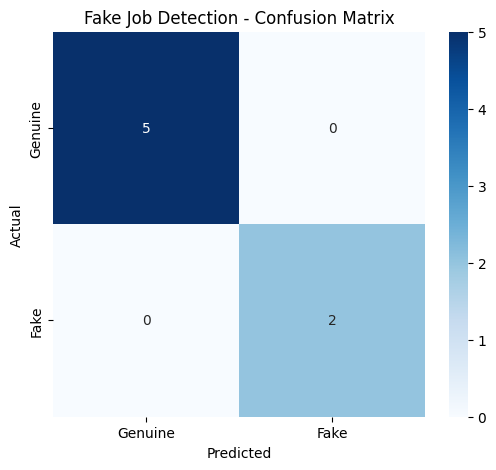

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fake"],
    yticklabels=["Genuine", "Fake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake Job Detection - Confusion Matrix")

plt.show()

In [19]:
joblib.dump(model, "fake_job_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\nModel saved successfully!")


Model saved successfully!


In [21]:
import joblib
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [6]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [12]:
import joblib
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

model = joblib.load("fake_job_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
job_title = input("Enter Job Title: ")

job_description = input(
    "Enter Job Description: "
)

job_requirements = input(
    "Enter Job Requirements: "
)


job_text = (
    job_title + " " +
    job_description + " " +
    job_requirements
)

Enter Job Title: Work From Home Data Entry
Enter Job Description: Earn 50000 per week. No experience required. Send your bank details and registration fee to start immediately
Enter Job Requirements: No experience required.


In [15]:
cleaned = clean_text(job_text)

In [16]:
vector = vectorizer.transform([cleaned])

In [17]:
prediction = model.predict(vector)[0]

probability = model.predict_proba(vector)[0]

In [18]:
print("\n==============================")
print("JOB POSTING ANALYSIS")
print("==============================")


if prediction == 1:

    print("Prediction: ⚠️ FAKE JOB POSTING")

    confidence = probability[1] * 100

else:

    print("Prediction: ✅ GENUINE JOB POSTING")

    confidence = probability[0] * 100


print(
    "Model confidence: {:.2f}%".format(
        confidence
    )
)


JOB POSTING ANALYSIS
Prediction: ⚠️ FAKE JOB POSTING
Model confidence: 64.20%
